# Development of new splitting metrics

In [17]:
import os, sys, importlib.util

# 1) Where Jupyter is currently running:
cwd = os.getcwd()
print("Notebook cwd:", cwd)

# 2) Compute the folder above (your project root):
project_root = os.path.abspath(os.path.join(cwd, os.pardir))
print("Project root:", project_root)
print("→ Contains:", os.listdir(project_root))

# 3) Inject it onto sys.path (highest priority):
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print("After hack, sys.path[0]:", sys.path[0])

# 4) Confirm Python can now see lmt_pkg:
print("After hack, spec(lmt_pkg):", importlib.util.find_spec("lmt_pkg"))

from lmt_pkg import lmt_final_implementation as lmt
from lmt_pkg import calibration_functions as calibration
from lmt_pkg import logitboost_j_implementation as logitboost
from lmt_pkg import composite_tree
from lmt_pkg import spline_splitting as spline

Notebook cwd: c:\Users\allis\Desktop\MITACS\LMT-calibration\Alternative tree (linear spline)
Project root: c:\Users\allis\Desktop\MITACS\LMT-calibration
→ Contains: ['.git', 'Alternative pruning', 'Alternative tree (linear spline)', 'Alternative tree (root multi-cuts)', 'Calibration testing', 'Construction and tests', 'desktop.ini', 'Documentation', 'lmt_pkg', 'Papers', 'README.md']
After hack, sys.path[0]: c:\Users\allis\Desktop\MITACS\LMT-calibration
After hack, spec(lmt_pkg): ModuleSpec(name='lmt_pkg', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000002699522C250>, origin='c:\\Users\\allis\\Desktop\\MITACS\\LMT-calibration\\lmt_pkg\\__init__.py', submodule_search_locations=['c:\\Users\\allis\\Desktop\\MITACS\\LMT-calibration\\lmt_pkg'])


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

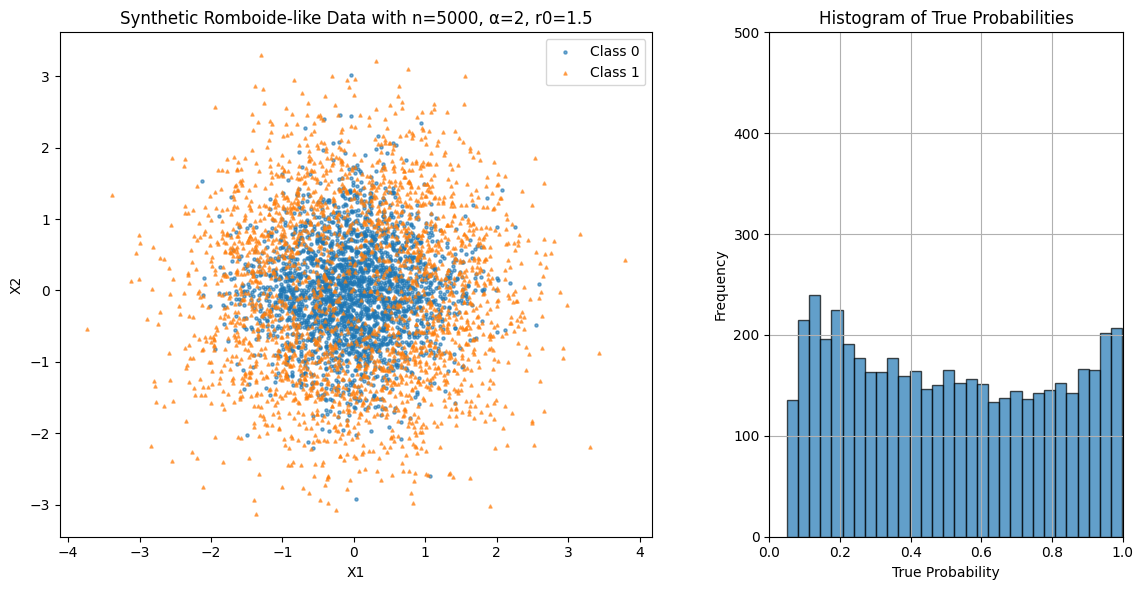

Proportion of positive samples: 0.50


In [19]:
# 1) PARAMETERS
n = 5000
alpha = 2 # controls sharpness of the circle boundary
r0 = 1.5   # target radius
# alpha = 5
# r0 = 1.0   # target radius
# 2) SIMULATE FEATURES from a normal distribution
np.random.seed(0)  # for reproducibility
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
r2 = np.abs(X1) + np.abs(X2)  # r^2 = |X1| + |X2|

# 3) DEFINE TRUE PROBABILITIES USING A SIGMOID ON r^2 - r0
p = 1 / (1 + np.exp(-alpha * (r2 - r0)))

# 4) SAMPLE OUTCOME y ~ Bernoulli(p)
y = np.random.binomial(1, p)


# Subplots for the scatter plot and the histogram
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, width_ratios=[2, 1])

# a) SCATTER PLOT
classes = np.unique(y)
ax1 = fig.add_subplot(gs[0])
ax1.set_title(f'Synthetic Romboide-like Data with n={n}, α={alpha}, r0={r0}')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
# Plot the points with different markers for each class
for cls, marker in zip(classes, ['o', '^']):
    ax1.scatter(
        X1[y==cls], 
        X2[y==cls], 
        alpha=0.6, 
        marker=marker, 
        label=f'Class {int(cls)}',
        s=5
    )
ax1.legend()

# b) HISTOGRAM OF PROBABILITIES
ax2 = fig.add_subplot(gs[1])
ax2.set_title('Histogram of True Probabilities')
ax2.set_xlabel('True Probability')
ax2.set_ylabel('Frequency')
ax2.hist(p, bins=30, alpha=0.7, edgecolor='black')
ax2.grid()
# Show the plots in equal proportions without blank spaces
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 500)
ax2.set_aspect('auto', adjustable='box')
ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# Proportion of positive samples
positive_proportion = np.mean(y)
print(f"Proportion of positive samples: {positive_proportion:.2f}")

In [20]:
p.shape

(5000,)

In [21]:
# import train_test_split
from sklearn.model_selection import train_test_split

# Full X dataset
X = np.column_stack((X1, X2))

# Step 1: Train (60%) + Temp (40%)
X_train, X_temp, y_train, y_temp, true_probs_train, true_probs_temp = train_test_split(X, y, p, test_size=0.4, random_state=42, stratify=y)

# Step 2: Validation (20%) + Test (20%) from Temp
X_val, X_test, y_val, y_test, true_probs_val, true_probs_test = train_test_split(X_temp, y_temp, true_probs_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train.shape, X_val.shape, X_test.shape

((3000, 2), (1000, 2), (1000, 2))

## Brier Score

In [22]:
spline_tree_auc = spline.grow_spline_tree(X_train, y_train, [0,1], max_depth=10, min_samples_leaf=20, purity_threshold=0.85, metric='auc', verbose=True)

Feature 0, tau = -1.25, AUC_L = 0.655, AUC_R = 0.584, Weighted AUC = 0.592
Feature 0, tau = -0.85, AUC_L = 0.685, AUC_R = 0.630, Weighted AUC = 0.641
Feature 0, tau = -0.54, AUC_L = 0.685, AUC_R = 0.669, Weighted AUC = 0.674
Feature 0, tau = -0.26, AUC_L = 0.682, AUC_R = 0.702, Weighted AUC = 0.694
Feature 0, tau = -0.02, AUC_L = 0.699, AUC_R = 0.711, Weighted AUC = 0.705
Feature 0, tau = 0.23, AUC_L = 0.704, AUC_R = 0.678, Weighted AUC = 0.694
Feature 0, tau = 0.50, AUC_L = 0.665, AUC_R = 0.666, Weighted AUC = 0.665
Feature 0, tau = 0.82, AUC_L = 0.616, AUC_R = 0.663, Weighted AUC = 0.625
Feature 0, tau = 1.25, AUC_L = 0.564, AUC_R = 0.669, Weighted AUC = 0.575
Feature 1, tau = -1.30, AUC_L = 0.659, AUC_R = 0.581, Weighted AUC = 0.589
Feature 1, tau = -0.87, AUC_L = 0.666, AUC_R = 0.649, Weighted AUC = 0.652
Feature 1, tau = -0.54, AUC_L = 0.697, AUC_R = 0.695, Weighted AUC = 0.696
Feature 1, tau = -0.27, AUC_L = 0.719, AUC_R = 0.722, Weighted AUC = 0.721
Feature 1, tau = -0.03, AUC_L

In [23]:
spline_tree_brier = spline.grow_spline_tree(X_train, y_train, [0,1], max_depth=10, min_samples_leaf=20, purity_threshold=0.85, metric='brier', verbose=True)

Feature 0, tau = -1.25, Brier_L = 0.173, Brier_R = 0.242, Weighted Brier = 0.235
Feature 0, tau = -0.85, Brier_L = 0.205, Brier_R = 0.233, Weighted Brier = 0.227
Feature 0, tau = -0.54, Brier_L = 0.217, Brier_R = 0.224, Weighted Brier = 0.222
Feature 0, tau = -0.26, Brier_L = 0.221, Brier_R = 0.217, Weighted Brier = 0.219
Feature 0, tau = -0.02, Brier_L = 0.218, Brier_R = 0.216, Weighted Brier = 0.217
Feature 0, tau = 0.23, Brier_L = 0.216, Brier_R = 0.224, Weighted Brier = 0.219
Feature 0, tau = 0.50, Brier_L = 0.225, Brier_R = 0.221, Weighted Brier = 0.224
Feature 0, tau = 0.82, Brier_L = 0.235, Brier_R = 0.209, Weighted Brier = 0.230
Feature 0, tau = 1.25, Brier_L = 0.245, Brier_R = 0.174, Weighted Brier = 0.237
Feature 1, tau = -1.30, Brier_L = 0.172, Brier_R = 0.243, Weighted Brier = 0.235
Feature 1, tau = -0.87, Brier_L = 0.204, Brier_R = 0.228, Weighted Brier = 0.224
Feature 1, tau = -0.54, Brier_L = 0.212, Brier_R = 0.216, Weighted Brier = 0.215
Feature 1, tau = -0.27, Brier_L 

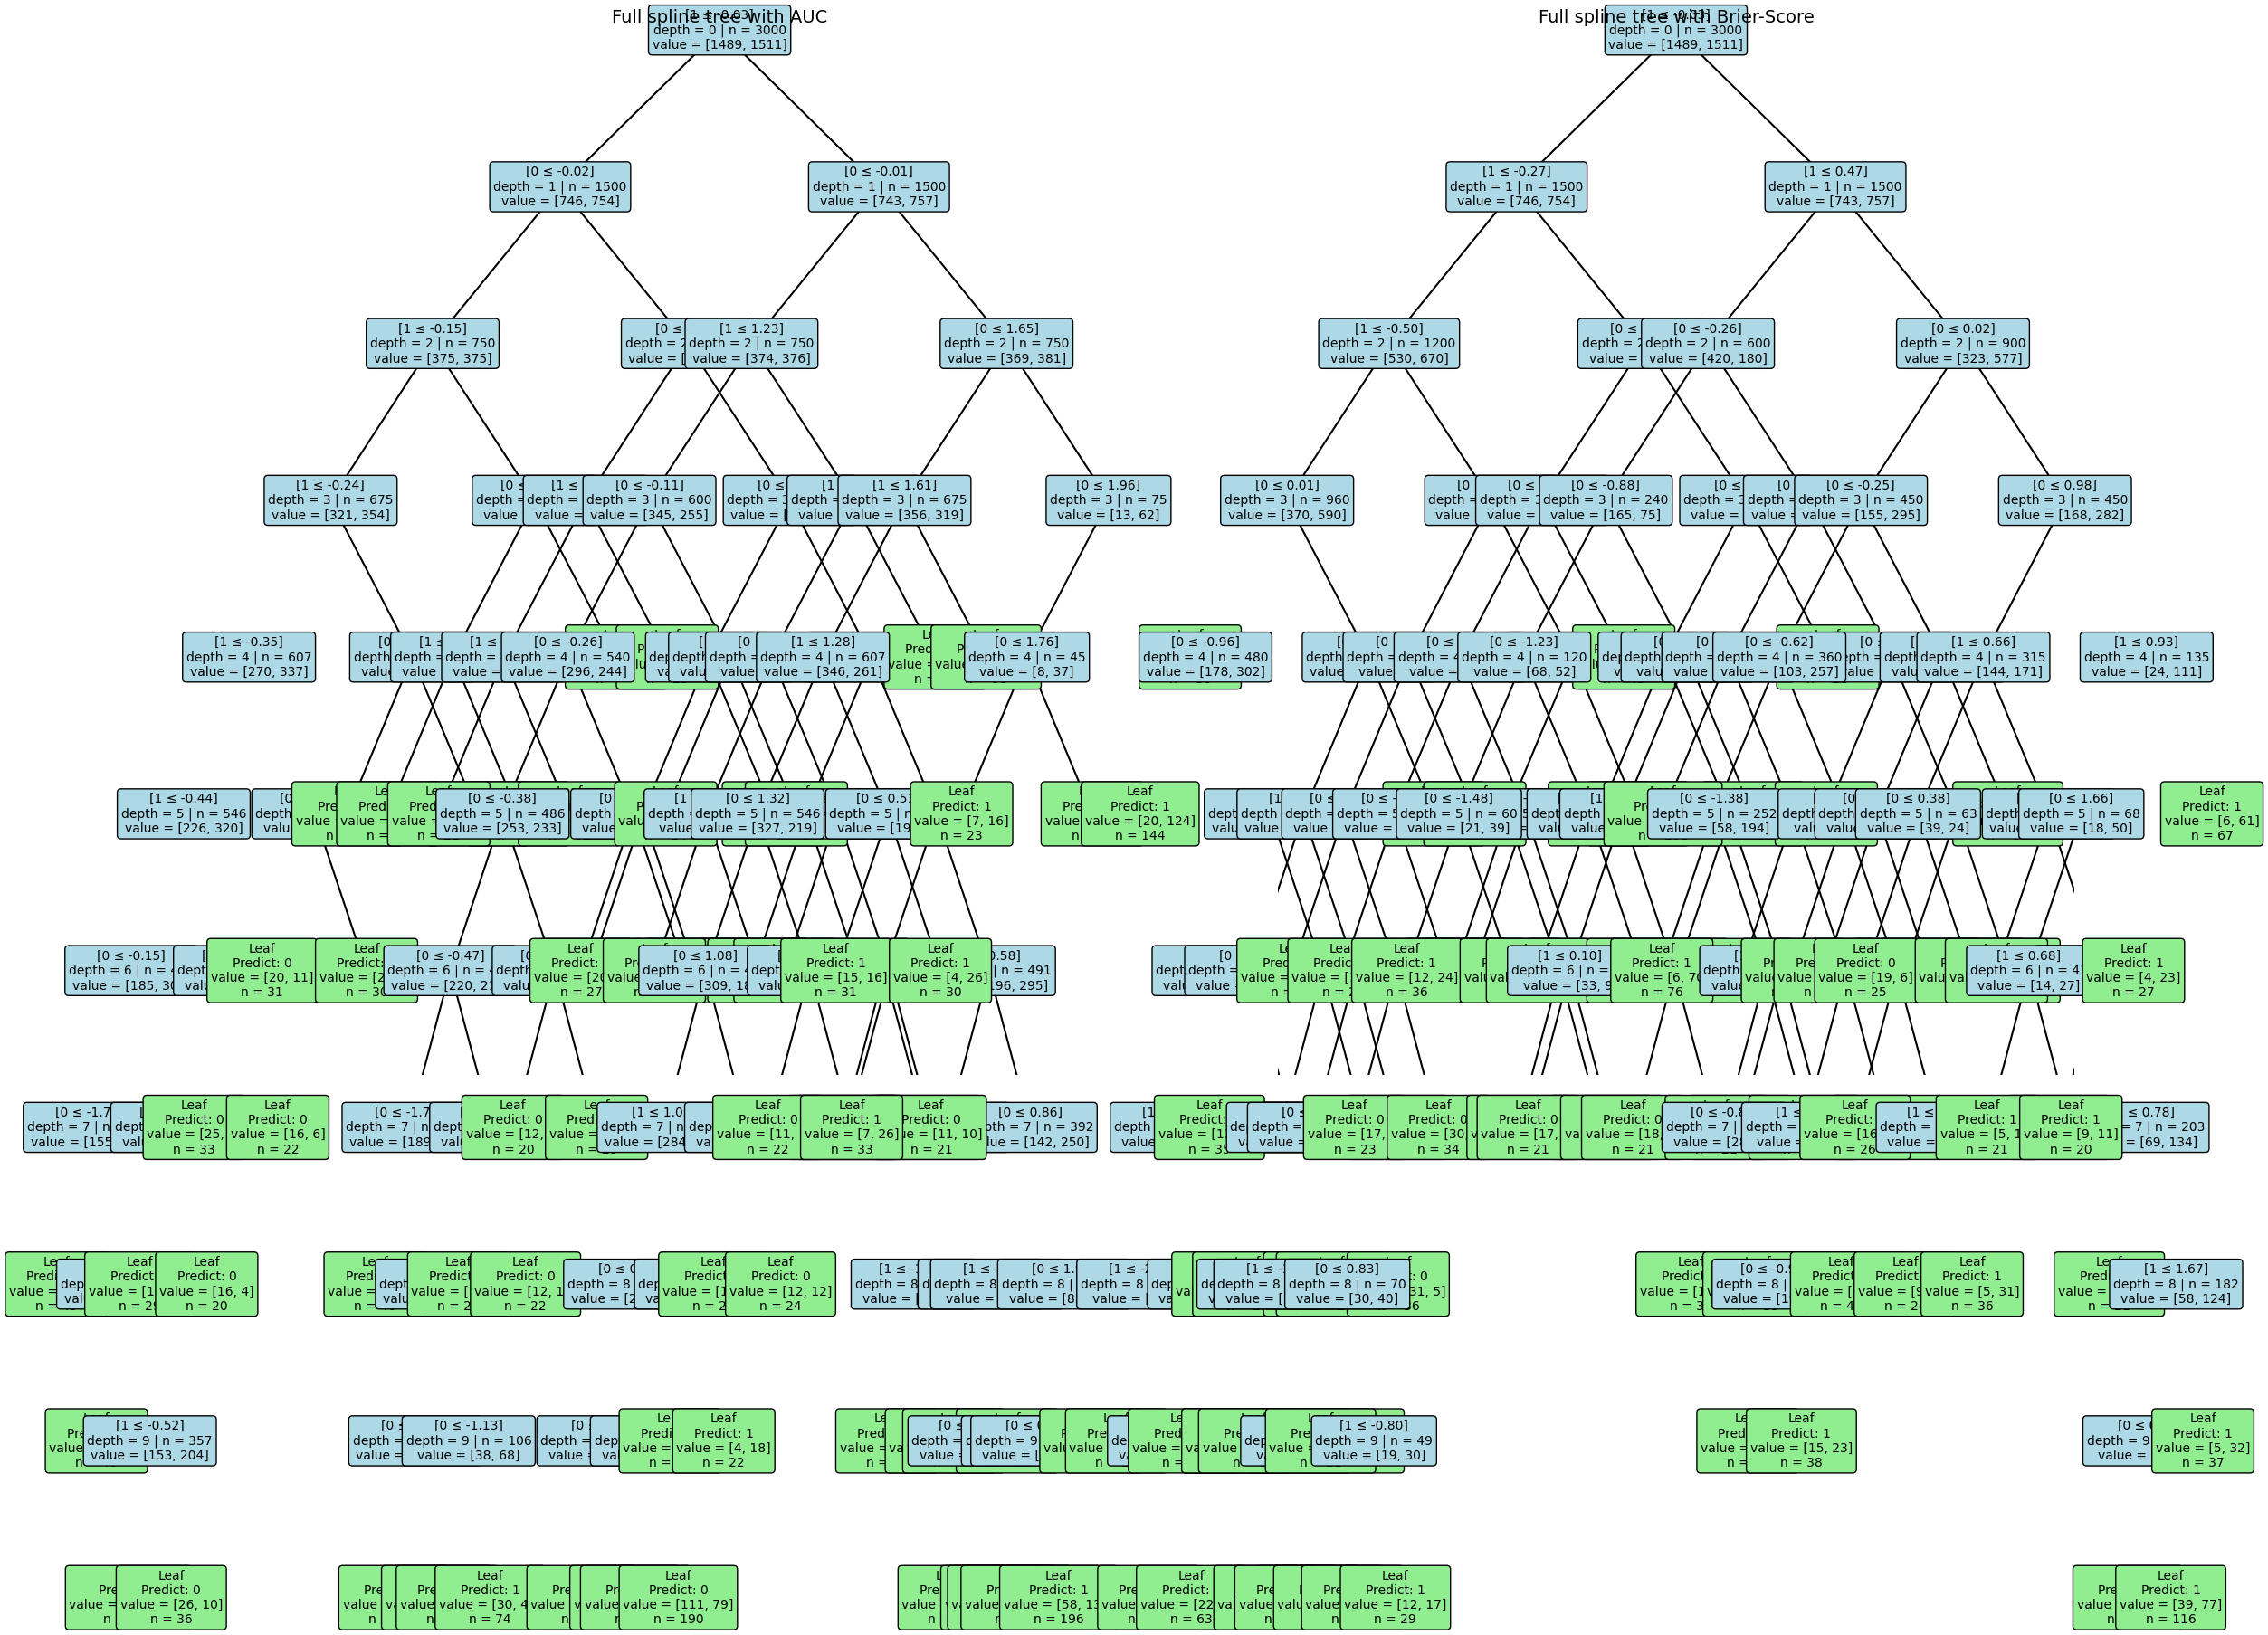

In [24]:
# Trees
fig, ax = plt.subplots(1, 2, figsize=(25, 15))
for axis in ax:
    axis.set_axis_off() 

#spline.plot_custom_tree_with_models(pruned_tree0, pruned_node_models0, X_train, ax=ax[0],title="Pruned Custom LMT with LogitBoost Models, threshold=0.60")
spline.plot_custom_tree(spline_tree_auc, ax=ax[0])
spline.plot_custom_tree(spline_tree_brier, ax=ax[1])


ax[0].set_title("Full spline tree with AUC", fontsize=14)
ax[1].set_title("Full spline tree with Brier-Score", fontsize=14)
plt.show()

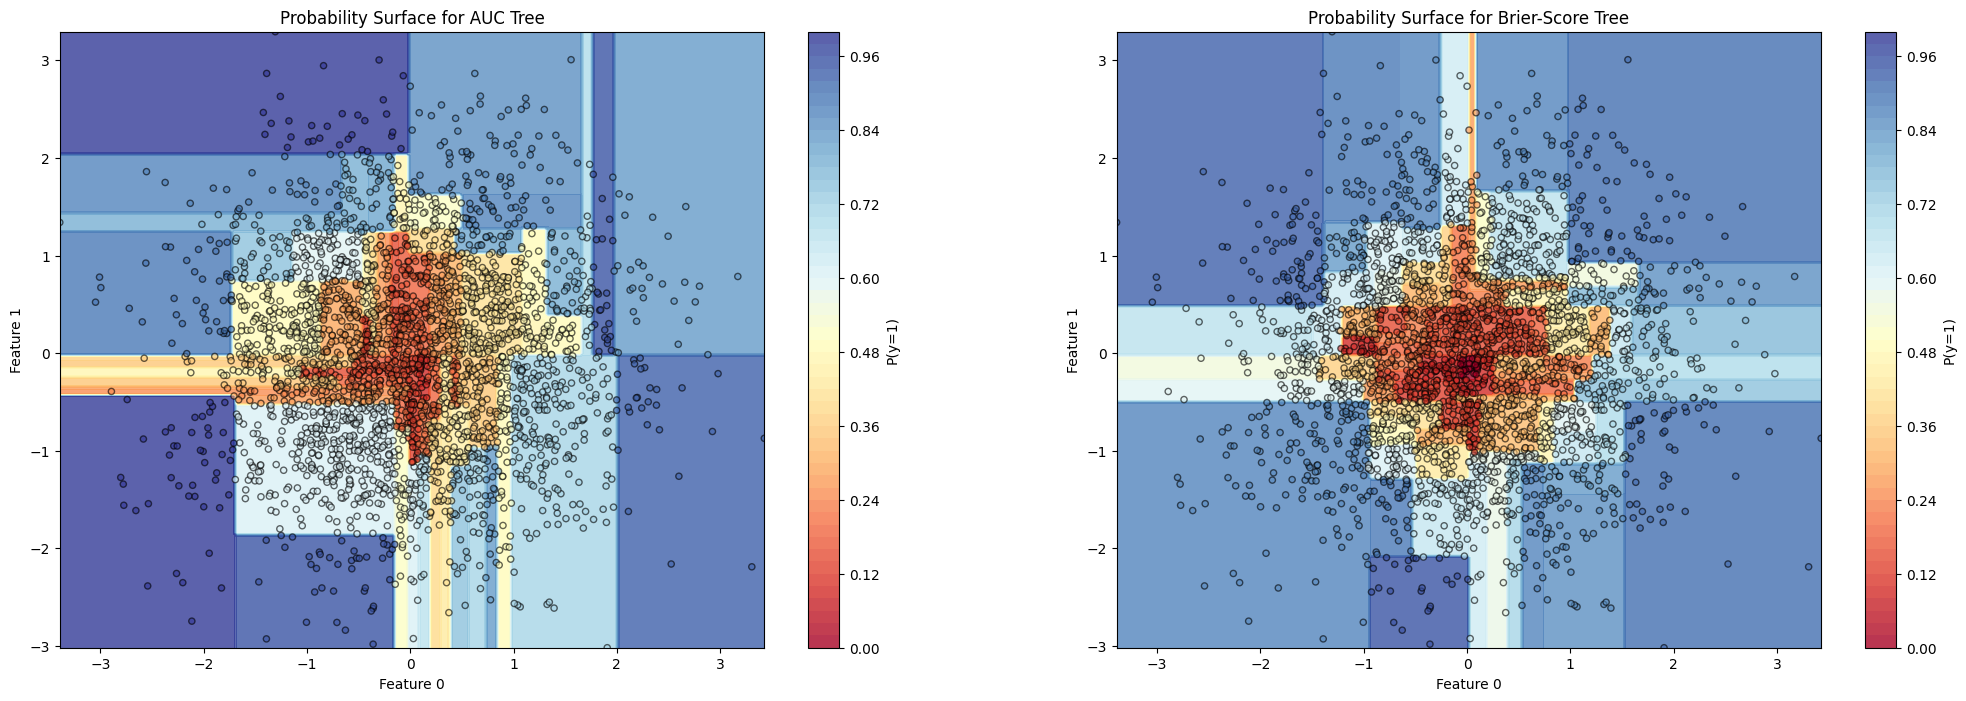

In [25]:
# Proability regions
fig, ax = plt.subplots(1, 2, figsize=(25, 8))

spline.plot_probability_surface_tree(spline_tree_auc, X_train, [0,1], ax=ax[0], title="Probability Surface for AUC Tree")
spline.plot_probability_surface_tree(spline_tree_brier, X_train, [0,1], ax=ax[1], title="Probability Surface for Brier-Score Tree")

plt.show()

Feature 0, tau = -1.25, AUC_L = 0.655, AUC_R = 0.584, Weighted AUC = 0.592
Feature 0, tau = -0.85, AUC_L = 0.685, AUC_R = 0.630, Weighted AUC = 0.641
Feature 0, tau = -0.54, AUC_L = 0.685, AUC_R = 0.669, Weighted AUC = 0.674
Feature 0, tau = -0.26, AUC_L = 0.682, AUC_R = 0.702, Weighted AUC = 0.694
Feature 0, tau = -0.02, AUC_L = 0.699, AUC_R = 0.711, Weighted AUC = 0.705
Feature 0, tau = 0.23, AUC_L = 0.704, AUC_R = 0.678, Weighted AUC = 0.694
Feature 0, tau = 0.50, AUC_L = 0.665, AUC_R = 0.666, Weighted AUC = 0.665
Feature 0, tau = 0.82, AUC_L = 0.616, AUC_R = 0.663, Weighted AUC = 0.625
Feature 0, tau = 1.25, AUC_L = 0.564, AUC_R = 0.669, Weighted AUC = 0.575
Feature 1, tau = -1.30, AUC_L = 0.659, AUC_R = 0.581, Weighted AUC = 0.589
Feature 1, tau = -0.87, AUC_L = 0.666, AUC_R = 0.649, Weighted AUC = 0.652
Feature 1, tau = -0.54, AUC_L = 0.697, AUC_R = 0.695, Weighted AUC = 0.696
Feature 1, tau = -0.27, AUC_L = 0.719, AUC_R = 0.722, Weighted AUC = 0.721
Feature 1, tau = -0.03, AUC_L

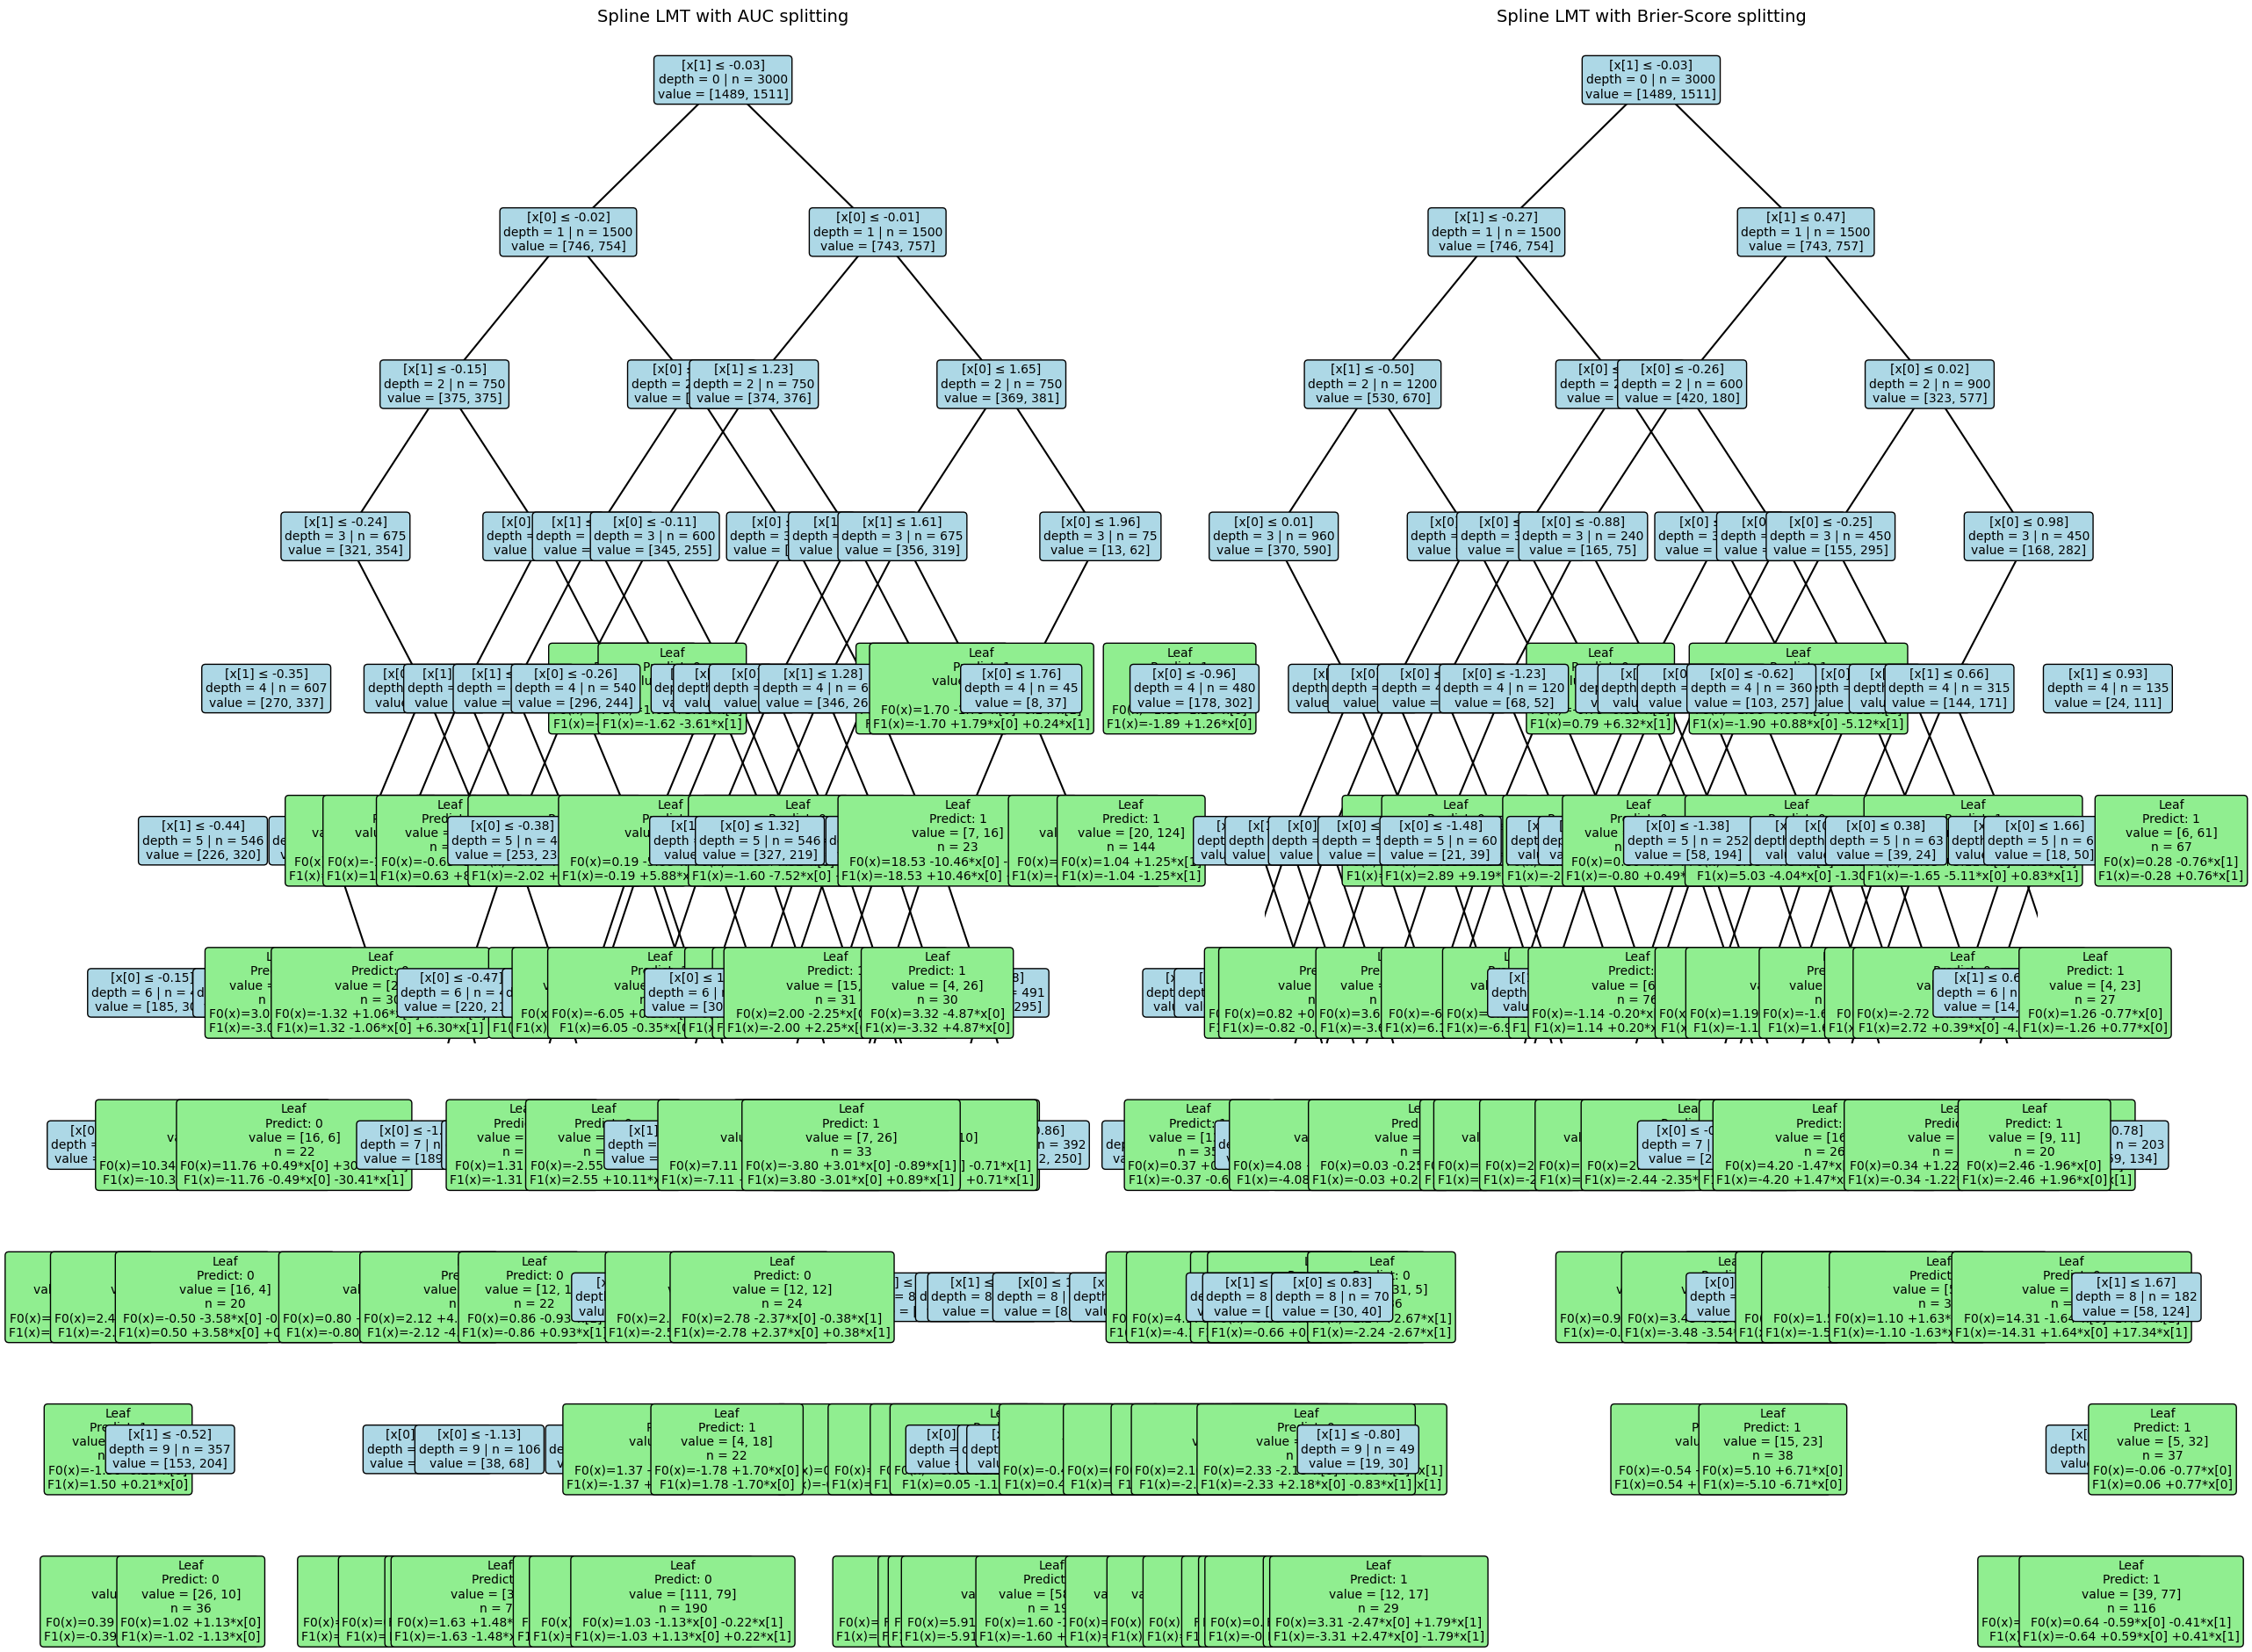

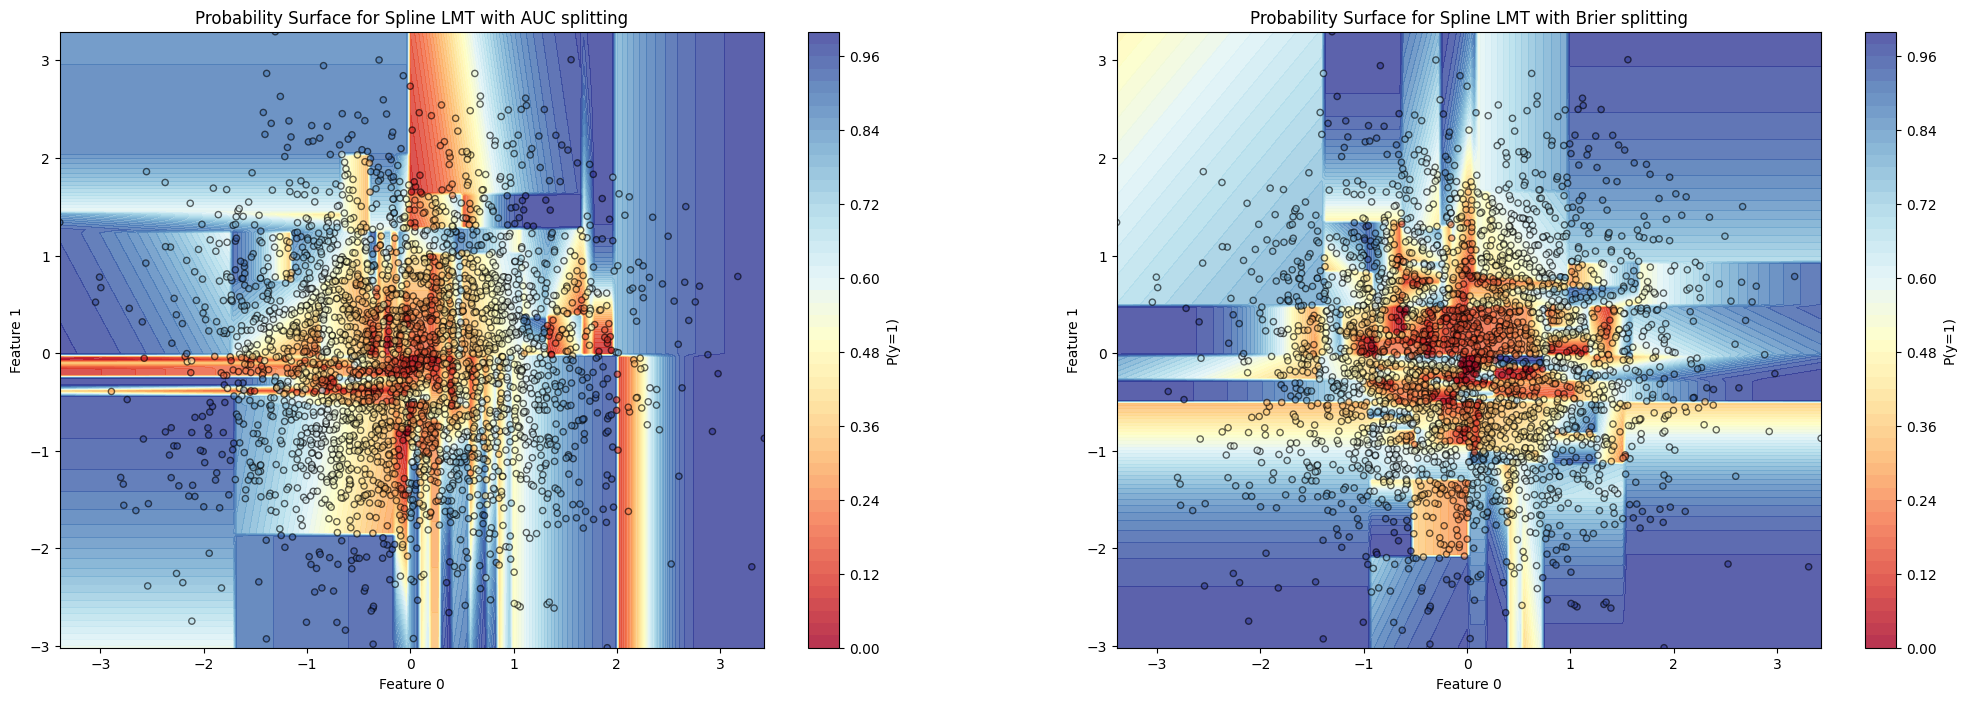

In [26]:
spline_lmt_auc, node_models_auc = spline.fit_logistic_model_tree_custom(X_train, y_train, [0,1], 10, 20, 0.85, metric='auc', verbose=True)
spline_lmt_brier, node_models_brier = spline.fit_logistic_model_tree_custom(X_train, y_train, [0,1], 10, 20, 0.85, metric='brier', verbose=True)

# Trees
fig, ax = plt.subplots(1, 2, figsize=(25, 15))
for axis in ax:
    axis.set_axis_off()
spline.plot_custom_tree_with_models(spline_lmt_auc, node_models_auc, X_train, ax=ax[0], title="Spline LMT with AUC splitting")
spline.plot_custom_tree_with_models(spline_lmt_brier, node_models_brier, X_train, ax=ax[1], title="Spline LMT with Brier splitting")
ax[0].set_title("Spline LMT with AUC splitting", fontsize=14)
ax[1].set_title("Spline LMT with Brier-Score splitting", fontsize=14)
plt.show()

# Proability regions
fig, ax = plt.subplots(1, 2, figsize=(25, 8))
spline.plot_probability_surface_custom_tree(spline_lmt_auc, node_models_auc, X_train, [0,1], ax=ax[0], title="Probability Surface for Spline LMT with AUC splitting")
spline.plot_probability_surface_custom_tree(spline_lmt_brier, node_models_brier, X_train, [0,1], ax=ax[1], title="Probability Surface for Spline LMT with Brier splitting")
plt.show()

# Development of cross-validation selection for $\delta$ pruning parameter

## Using Brier-Score for final selection of $\delta$

In [33]:
import time
# Step 2: Select optimal delta using cross-validation on validation set
deltas = np.linspace(0.60, 0.90, 20)
# deltas_gain = np.linspace(0, 0.05, 20)
deltas_local = np.linspace(0, 0.0025, 20)

start_time = time.time()

# For AUC splitting 
delta_star_auc_local = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_auc, node_models_auc,
    deltas=deltas_local, K=5,
    metric_eval='brier',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='local',  # or 'original'
    verbose=True
    ,true_probs=true_probs_val  # Pass true probabilities for evaluation
)
print(f"Time taken for CV delta pruning (AUC splitting, Local Gain method): {time.time() - start_time:.2f} seconds")

delta_star_auc_og = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_auc, node_models_auc,
    deltas=deltas, K=5,
    metric_eval='brier',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='original',  # or 'original'
    verbose=False
    ,true_probs=true_probs_val  # Pass true probabilities for evaluation
)
print(f"Time taken for CV delta pruning (AUC splitting, Original method): {time.time() - start_time:.2f} seconds")


# For Brier splitting
delta_star_brier_local = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_brier, node_models_brier,
    deltas=deltas_local, K=5,
    metric_eval='brier',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='local',  # or 'original'
    verbose=True
    ,true_probs=true_probs_val  # Pass true probabilities for evaluation
)
print(f"Time taken for CV delta pruning (Brier splitting, Local Gain method): {time.time() - start_time:.2f} seconds")

delta_star_brier_og = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_brier, node_models_brier,
    deltas=deltas, K=5,
    metric_eval='brier',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='original',  # or 'original'
    verbose=False
    ,true_probs=true_probs_val  # Pass true probabilities for evaluation
)
print(f"Time taken for CV delta pruning (Brier splitting, Original method): {time.time() - start_time:.2f} seconds")


# Step 3: Apply final pruning using delta_star

# For AUC splitting
# Local Gain pruning
final_root_auc_local, final_models_auc_local = spline.regression_pruning_gain_local(
    X_train, y_train, spline_lmt_auc, node_models_auc, delta=delta_star_auc_local, verbose=True
)

# Original pruning
final_root_auc_og, final_models_auc_og = spline.regression_pruning_spline_bfs(
    X_train, y_train, spline_lmt_auc, node_models_auc, threshold=delta_star_auc_og, verbose=False
)

# For Brier splitting
# Local Gain pruning
final_root_brier_local, final_models_brier_local = spline.regression_pruning_gain_local(
    X_train, y_train, spline_lmt_brier, node_models_brier, delta=delta_star_brier_local, verbose=True
)

# Original pruning
final_root_brier_og, final_models_brier_og = spline.regression_pruning_spline_bfs(
    X_train, y_train, spline_lmt_brier, node_models_brier, threshold=delta_star_brier_og, verbose=False
)

[Node 140] AUC_parent=0.4947, Weighted_AUC_children=0.7187, Gain=0.2241
[Node 70] AUC_parent=0.7396, Weighted_AUC_children=0.7228, Gain=-0.0168
→ Pruning node 70 (Gain=-0.0168 < delta=0.0)
[Node 139] AUC_parent=0.6978, Weighted_AUC_children=0.7657, Gain=0.0680
[Node 107] AUC_parent=0.8150, Weighted_AUC_children=0.6860, Gain=-0.1290
→ Pruning node 107 (Gain=-0.1290 < delta=0.0)
[Node 138] AUC_parent=0.7126, Weighted_AUC_children=0.7132, Gain=0.0006
[Node 132] AUC_parent=0.7016, Weighted_AUC_children=0.7106, Gain=0.0090
[Node 137] AUC_parent=0.8125, Weighted_AUC_children=0.6218, Gain=-0.1907
→ Pruning node 137 (Gain=-0.1907 < delta=0.0)
[Node 130] AUC_parent=0.7035, Weighted_AUC_children=0.6449, Gain=-0.0585
→ Pruning node 130 (Gain=-0.0585 < delta=0.0)
[Fold 0] Delta=0.0000, brier=0.0450
[Node 140] AUC_parent=0.4947, Weighted_AUC_children=0.7187, Gain=0.2241
[Node 70] AUC_parent=0.7396, Weighted_AUC_children=0.7228, Gain=-0.0168
→ Pruning node 70 (Gain=-0.0168 < delta=0.0001315789473684

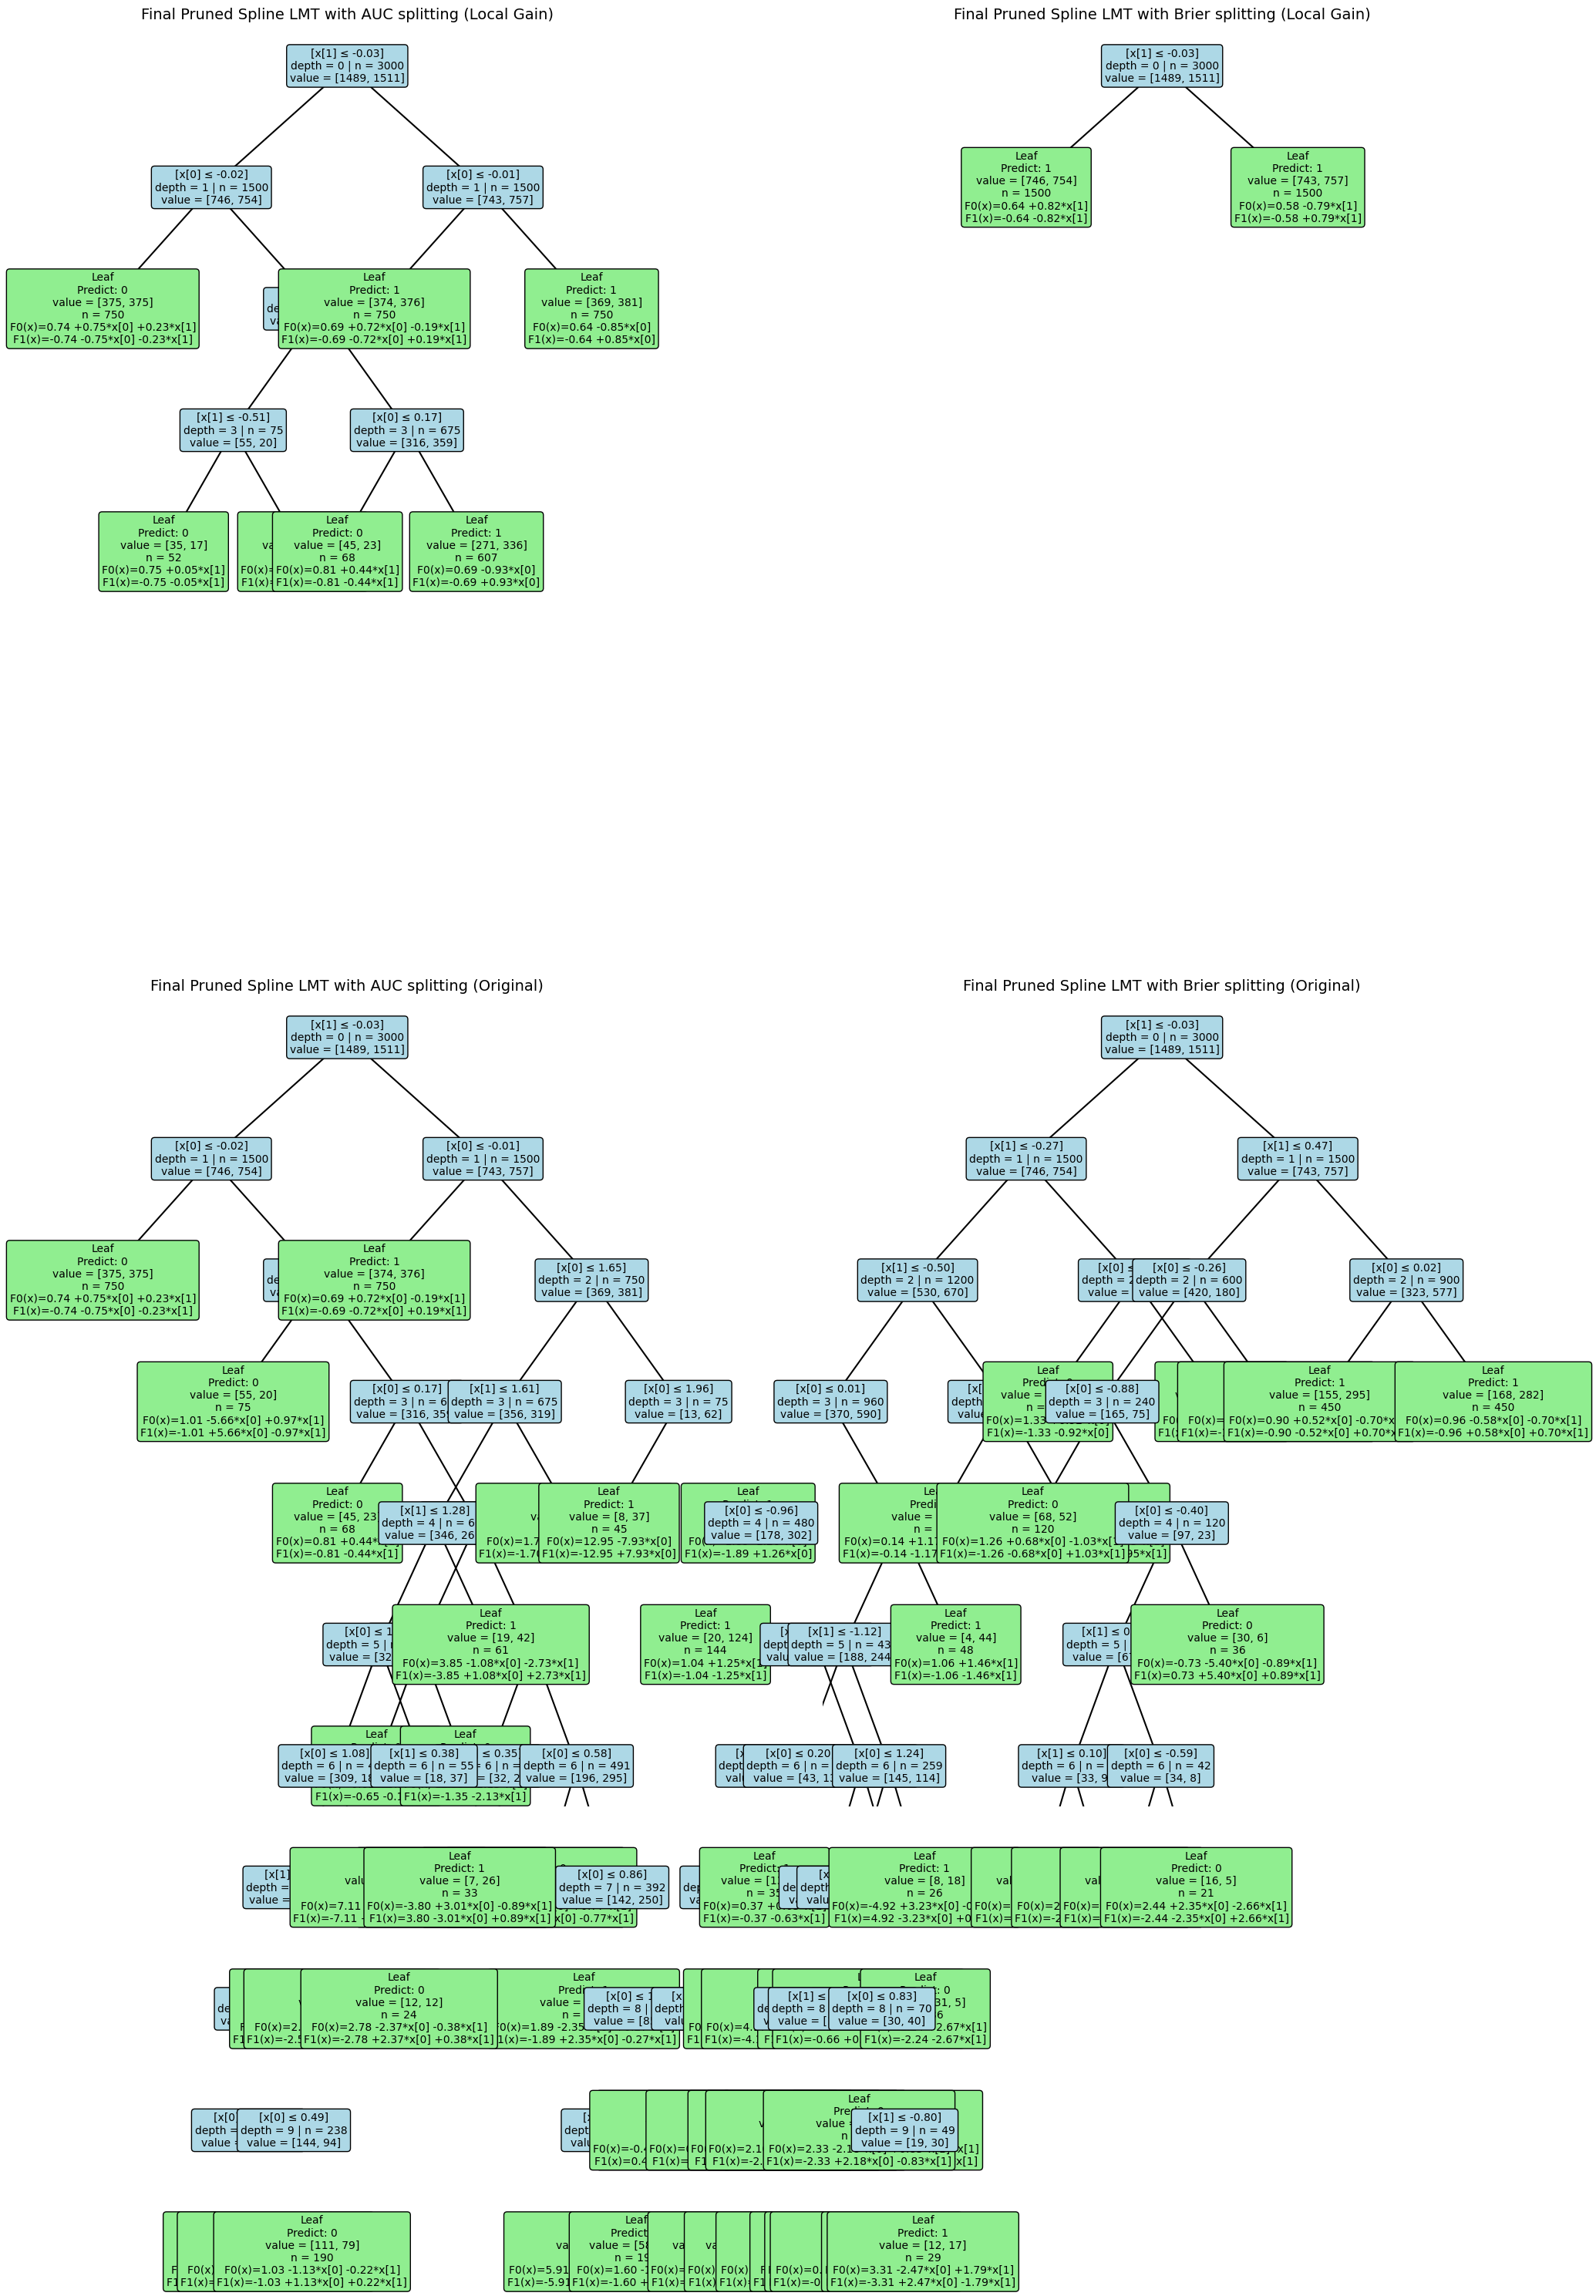

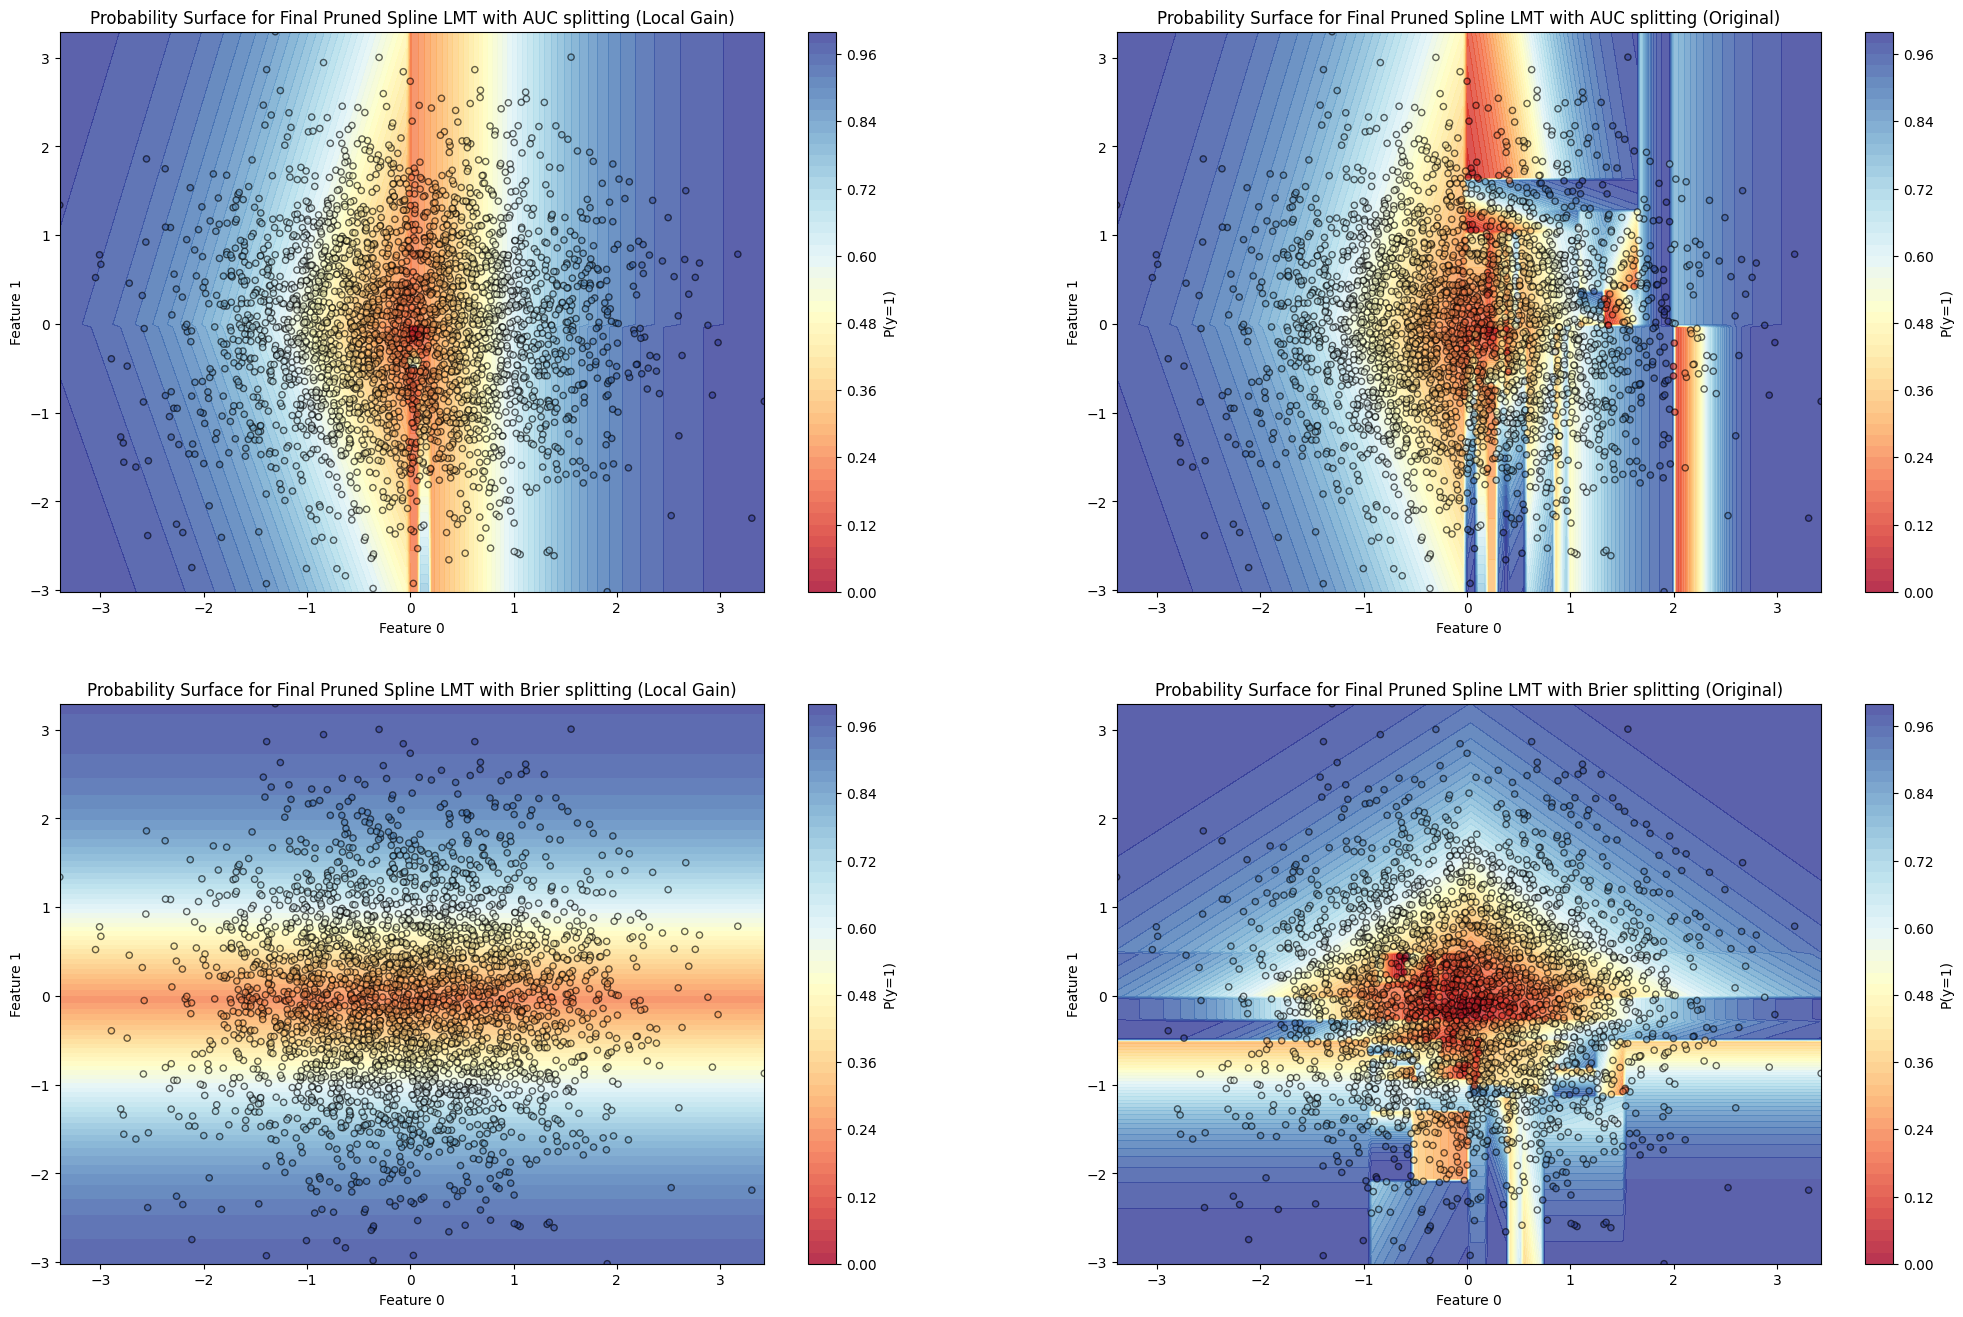

In [34]:
# Graph of the final pruned trees of the four models
fig, ax = plt.subplots(2, 2, figsize=(25, 30))
for axis in ax.flatten():
    axis.set_axis_off() 
spline.plot_custom_tree_with_models(final_root_auc_local, final_models_auc_local, X_train, ax=ax[0, 0], title="Final Pruned Spline LMT with AUC splitting (Local Gain)")
ax[0,0].set_title("Final Pruned Spline LMT with AUC splitting (Local Gain)", fontsize=14)
spline.plot_custom_tree_with_models(final_root_auc_og, final_models_auc_og, X_train, ax=ax[1, 0], title="Final Pruned Spline LMT with AUC splitting (Original)")
ax[1,0].set_title("Final Pruned Spline LMT with AUC splitting (Original)", fontsize=14)

spline.plot_custom_tree_with_models(final_root_brier_local, final_models_brier_local, X_train, ax=ax[0, 1], title="Final Pruned Spline LMT with Brier splitting (Local Gain)")
ax[0,1].set_title("Final Pruned Spline LMT with Brier splitting (Local Gain)", fontsize=14)
spline.plot_custom_tree_with_models(final_root_brier_og, final_models_brier_og, X_train, ax=ax[1, 1], title="Final Pruned Spline LMT with Brier splitting (Original)")
ax[1,1].set_title("Final Pruned Spline LMT with Brier splitting (Original)", fontsize=14)

plt.show()


# Proability regions of the four final pruned models
fig, ax = plt.subplots(2, 2, figsize=(25, 16))
spline.plot_probability_surface_custom_tree(final_root_auc_local, final_models_auc_local, X_train, [0,1], ax=ax[0, 0], title="Probability Surface for Final Pruned Spline LMT with AUC splitting (Local Gain)")
spline.plot_probability_surface_custom_tree(final_root_auc_og, final_models_auc_og, X_train, [0,1], ax=ax[0, 1], title="Probability Surface for Final Pruned Spline LMT with AUC splitting (Original)")
spline.plot_probability_surface_custom_tree(final_root_brier_local, final_models_brier_local, X_train, [0,1], ax=ax[1, 0], title="Probability Surface for Final Pruned Spline LMT with Brier splitting (Local Gain)")
spline.plot_probability_surface_custom_tree(final_root_brier_og, final_models_brier_og, X_train, [0,1], ax=ax[1, 1], title="Probability Surface for Final Pruned Spline LMT with Brier splitting (Original)")
plt.show()

In [35]:
print("delta_star_auc_local:", delta_star_auc_local)
print("delta_star_auc_og:", delta_star_auc_og)
print("delta_star_brier_local:", delta_star_brier_local)
print("delta_star_brier_og:", delta_star_brier_og)

delta_star_auc_local: 0.00013157894736842105
delta_star_auc_og: 0.7389473684210526
delta_star_brier_local: 0.0
delta_star_brier_og: 0.7389473684210526


## Using *log-loss* for final selection of $\delta$

In [30]:
# Step 2: Select optimal delta using cross-validation on validation set
print("LOG-LOSS METRIC FOR EVALUATION")
# deltas = np.linspace(0.60, 0.90, 20)
# deltas_gain = np.linspace(0, 0.05, 20)
# deltas_local = np.linspace(-0.002, 0.002, 20)

start_time = time.time()

# For AUC splitting 
delta_star_auc_local = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_auc, node_models_auc,
    deltas=deltas_local, K=5,
    metric_eval='log-loss',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='local',  # or 'original'
    verbose=True
)
print(f"Time taken for CV delta pruning (AUC splitting, Local Gain method): {time.time() - start_time:.2f} seconds")

# delta_star_auc_gain = spline.cv_delta_pruning(
#     X_val, y_val, spline_lmt_auc, node_models_auc,
#     deltas=deltas_gain, K=5,
#     metric_eval='log-loss',  # or 'log-loss'
#     metric_prune='auc',  # the metric used during pruning
#     method='gain',  # or 'original'
#     verbose=True
# )
# print(f"Time taken for CV delta pruning (AUC splitting, Gain method): {time.time() - start_time:.2f} seconds")

delta_star_auc_og = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_auc, node_models_auc,
    deltas=deltas, K=5,
    metric_eval='log-loss',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='original',  # or 'original'
    verbose=True
)
print(f"Time taken for CV delta pruning (AUC splitting, Original method): {time.time() - start_time:.2f} seconds")


# For Brier splitting
delta_star_brier_local = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_brier, node_models_brier,
    deltas=deltas_local, K=5,
    metric_eval='log-loss',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='local',  # or 'original'
    verbose=True
)
print(f"Time taken for CV delta pruning (Brier splitting, Local Gain method): {time.time() - start_time:.2f} seconds")

# delta_star_brier_gain = spline.cv_delta_pruning(
#     X_val, y_val, spline_lmt_brier, node_models_brier,
#     deltas=deltas_gain, K=5,
#     metric_eval='log-loss',  # or 'log-loss'
#     metric_prune='auc',  # the metric used during pruning
#     method='gain',  # or 'original'
#     verbose=True
# )
# print(f"Time taken for CV delta pruning (Brier splitting, Gain method): {time.time() - start_time:.2f} seconds")

delta_star_brier_og = spline.cv_delta_pruning(
    X_val, y_val, spline_lmt_brier, node_models_brier,
    deltas=deltas, K=5,
    metric_eval='log-loss',  # or 'log-loss'
    metric_prune='auc',  # the metric used during pruning
    method='original',  # or 'original'
    verbose=True
)
print(f"Time taken for CV delta pruning (Brier splitting, Original method): {time.time() - start_time:.2f} seconds")


# Step 3: Apply final pruning using delta_star

# For AUC splitting
# Local Gain pruning
final_root_auc_local, final_models_auc_local = spline.regression_pruning_gain_local(
    X_train, y_train, spline_lmt_auc, node_models_auc, delta=delta_star_auc_local, verbose=True
)
# # Gain pruning
# final_root_auc_gain, final_models_auc_gain = spline.regression_pruning_gain(
#     X_train, y_train, spline_lmt_auc, node_models_auc, delta=delta_star_auc_gain, verbose=True
# )
# Original pruning
final_root_auc_og, final_models_auc_og = spline.regression_pruning_spline_bfs(
    X_train, y_train, spline_lmt_auc, node_models_auc, threshold=delta_star_auc_og, verbose=True
)

# For Brier splitting
# Local Gain pruning
final_root_brier_local, final_models_brier_local = spline.regression_pruning_gain_local(
    X_train, y_train, spline_lmt_brier, node_models_brier, delta=delta_star_brier_local, verbose=True
)

# # Gain pruning
# final_root_brier_gain, final_models_brier_gain = spline.regression_pruning_gain(
#     X_train, y_train, spline_lmt_brier, node_models_brier, delta=delta_star_brier_gain, verbose=True
# )
# Original pruning
final_root_brier_og, final_models_brier_og = spline.regression_pruning_spline_bfs(
    X_train, y_train, spline_lmt_brier, node_models_brier, threshold=delta_star_brier_og, verbose=True
)


LOG-LOSS METRIC FOR EVALUATION
[Node 140] AUC_parent=0.4947, Weighted_AUC_children=0.7187, Gain=0.2241
[Node 70] AUC_parent=0.7396, Weighted_AUC_children=0.7228, Gain=-0.0168
→ Pruning node 70 (Gain=-0.0168 < delta=-0.002)
[Node 139] AUC_parent=0.6978, Weighted_AUC_children=0.7657, Gain=0.0680
[Node 107] AUC_parent=0.8150, Weighted_AUC_children=0.6860, Gain=-0.1290
→ Pruning node 107 (Gain=-0.1290 < delta=-0.002)
[Node 138] AUC_parent=0.7126, Weighted_AUC_children=0.7132, Gain=0.0006
[Node 132] AUC_parent=0.7016, Weighted_AUC_children=0.7106, Gain=0.0090
[Node 137] AUC_parent=0.8125, Weighted_AUC_children=0.6218, Gain=-0.1907
→ Pruning node 137 (Gain=-0.1907 < delta=-0.002)
[Node 130] AUC_parent=0.7035, Weighted_AUC_children=0.6449, Gain=-0.0585
→ Pruning node 130 (Gain=-0.0585 < delta=-0.002)
[Fold 0] Delta=-0.0020, log-loss=0.6260
[Node 140] AUC_parent=0.4947, Weighted_AUC_children=0.7187, Gain=0.2241
[Node 70] AUC_parent=0.7396, Weighted_AUC_children=0.7228, Gain=-0.0168
→ Pruning n

LOG-LOSS METRIC FOR SELECTING DELTA


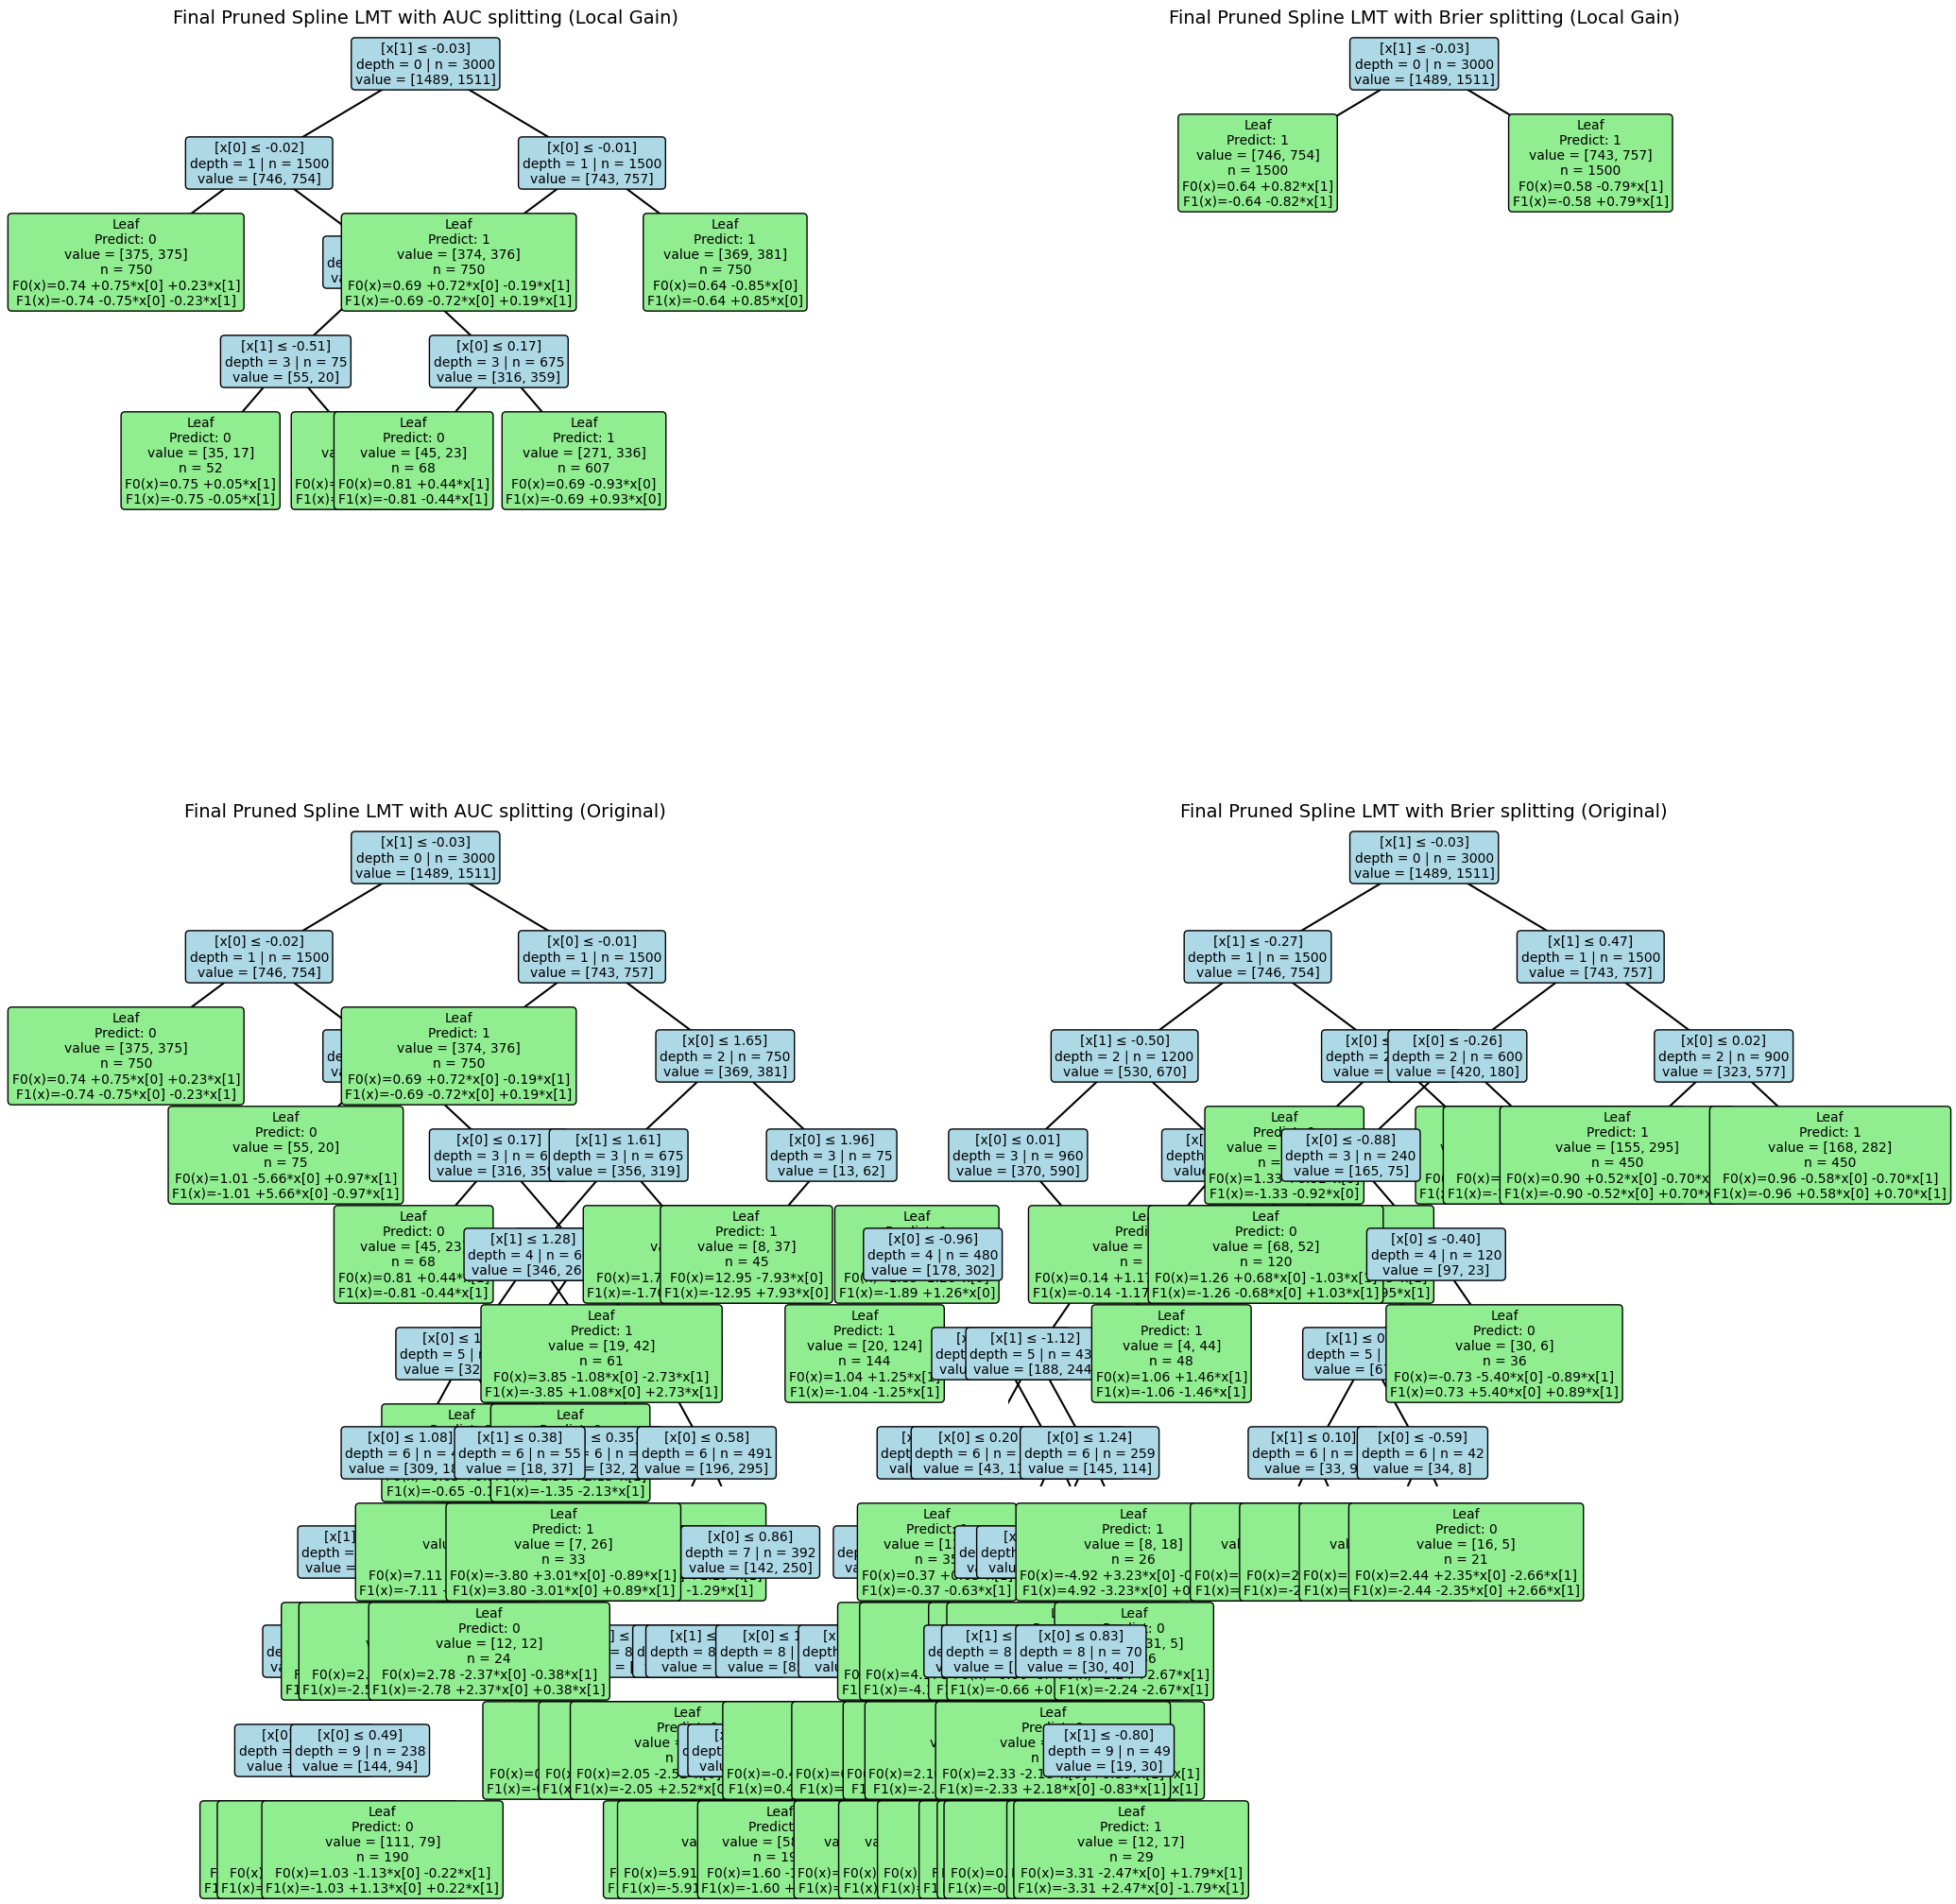

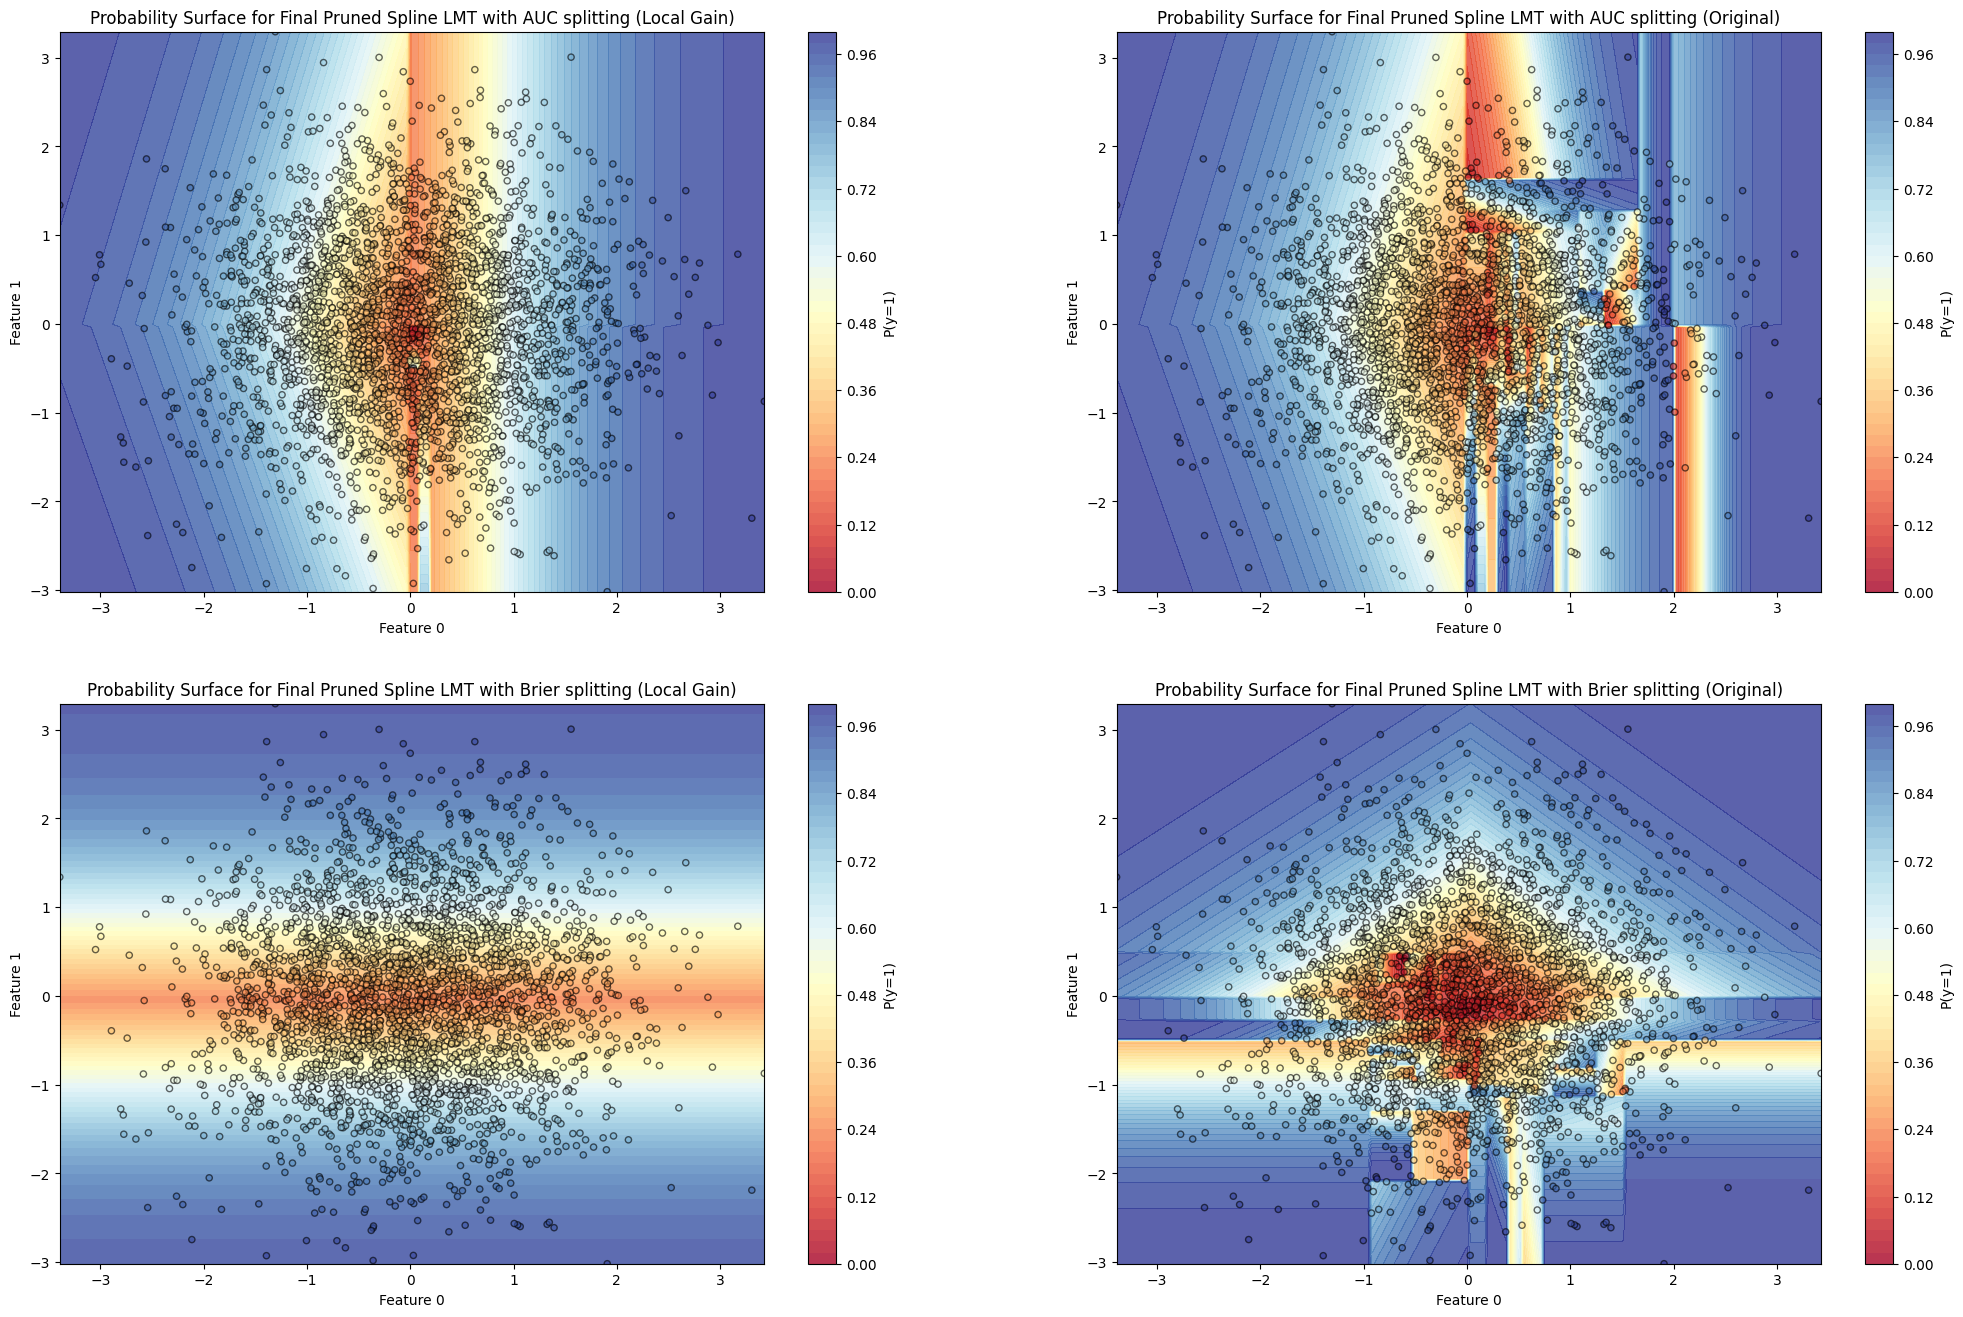

In [31]:
# Graph of the final pruned trees of the four models
print("LOG-LOSS METRIC FOR SELECTING DELTA")
fig, ax = plt.subplots(2, 2, figsize=(25, 20))
for axis in ax.flatten():
    axis.set_axis_off() 
spline.plot_custom_tree_with_models(final_root_auc_local, final_models_auc_local, X_train, ax=ax[0, 0], title="Final Pruned Spline LMT with AUC splitting (Local Gain)")
ax[0,0].set_title("Final Pruned Spline LMT with AUC splitting (Local Gain)", fontsize=14)
# spline.plot_custom_tree_with_models(final_root_auc_gain, final_models_auc_gain, X_train, ax=ax[1, 0], title="Final Pruned Spline LMT with AUC splitting (Gain)")
# ax[1,0].set_title("Final Pruned Spline LMT with AUC splitting (Gain)", fontsize=14)
spline.plot_custom_tree_with_models(final_root_auc_og, final_models_auc_og, X_train, ax=ax[1, 0], title="Final Pruned Spline LMT with AUC splitting (Original)")
ax[1,0].set_title("Final Pruned Spline LMT with AUC splitting (Original)", fontsize=14)

spline.plot_custom_tree_with_models(final_root_brier_local, final_models_brier_local, X_train, ax=ax[0, 1], title="Final Pruned Spline LMT with Brier splitting (Local Gain)")
ax[0,1].set_title("Final Pruned Spline LMT with Brier splitting (Local Gain)", fontsize=14)
# spline.plot_custom_tree_with_models(final_root_brier_gain, final_models_brier_gain, X_train, ax=ax[1, 1], title="Final Pruned Spline LMT with Brier splitting (Gain)")
# ax[1,1].set_title("Final Pruned Spline LMT with Brier splitting (Gain)", fontsize=14)
spline.plot_custom_tree_with_models(final_root_brier_og, final_models_brier_og, X_train, ax=ax[1, 1], title="Final Pruned Spline LMT with Brier splitting (Original)")
ax[1,1].set_title("Final Pruned Spline LMT with Brier splitting (Original)", fontsize=14)
plt.show()


# Proability regions of the four final pruned models
fig, ax = plt.subplots(2, 2, figsize=(25, 16))
spline.plot_probability_surface_custom_tree(final_root_auc_local, final_models_auc_local, X_train, [0,1], ax=ax[0, 0], title="Probability Surface for Final Pruned Spline LMT with AUC splitting (Local Gain)")
# spline.plot_probability_surface_custom_tree(final_root_auc_gain, final_models_auc_gain, X_train, [0,1], ax=ax[0, 1], title="Probability Surface for Final Pruned Spline LMT with AUC splitting (Gain)")
spline.plot_probability_surface_custom_tree(final_root_auc_og, final_models_auc_og, X_train, [0,1], ax=ax[0, 1], title="Probability Surface for Final Pruned Spline LMT with AUC splitting (Original)")
spline.plot_probability_surface_custom_tree(final_root_brier_local, final_models_brier_local, X_train, [0,1], ax=ax[1, 0], title="Probability Surface for Final Pruned Spline LMT with Brier splitting (Local Gain)")
# spline.plot_probability_surface_custom_tree(final_root_brier_gain, final_models_brier_gain, X_train, [0,1], ax=ax[1, 1], title="Probability Surface for Final Pruned Spline LMT with Brier splitting (Gain)")
spline.plot_probability_surface_custom_tree(final_root_brier_og, final_models_brier_og, X_train, [0,1], ax=ax[1, 1], title="Probability Surface for Final Pruned Spline LMT with Brier splitting (Original)")
plt.show()


In [32]:
print("delta_star_auc_local:", delta_star_auc_local)
# print("delta_star_auc_gain:", delta_star_auc_gain)
print("delta_star_auc_og:", delta_star_auc_og)
print("delta_star_brier_local:", delta_star_brier_local)
# print("delta_star_brier_gain:", delta_star_brier_gain)
print("delta_star_brier_og:", delta_star_brier_og)

delta_star_auc_local: -0.0014526315789473684
delta_star_auc_og: 0.7642105263157895
delta_star_brier_local: -0.002
delta_star_brier_og: 0.7452631578947368
